## `Import Libraries`

In [1]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score
import tensorflow as tf
from kerastuner import RandomSearch
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


/tmp/ipython-input-2209625010.py:13: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner import RandomSearch


## `Get the Dataset`

In [3]:
# read dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


* 0 for not survived 1 for survived
* parch -> # of parents and childrens





## `EDA`

In [4]:
# rename columns
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')
df.columns

Index(['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')

In [5]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    object 
 4   sex          891 non-null    object 
 5   age          714 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   ticket       891 non-null    object 
 9   fare         891 non-null    float64
 10  cabin        204 non-null    object 
 11  embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# stats
df.describe()

,passengerid,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# check NaNs
df.isna().sum().sort_values(ascending=False)

,0
cabin,687
age,177
embarked,2
passengerid,0
name,0
pclass,0
survived,0
sex,0
parch,0
sibsp,0


* drop cabin feature -> so many nulles
* fill nans in age with mean
* fill nans in embarked with mode  

In [8]:
# Columns that has NaNs
df.columns[df.isna().any()].tolist()

['age', 'cabin', 'embarked']

## `Visualization`

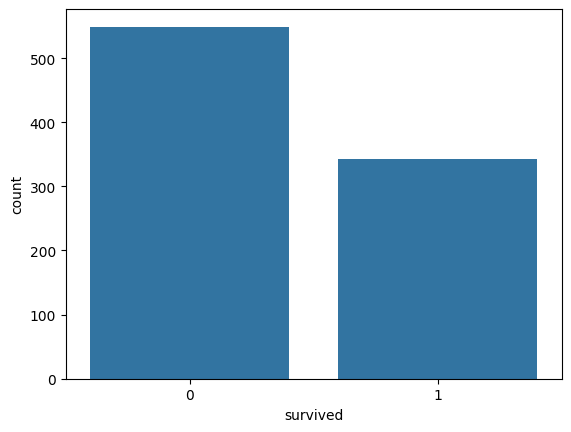

In [9]:
sns.countplot(data=df, x="survived")
plt.show()

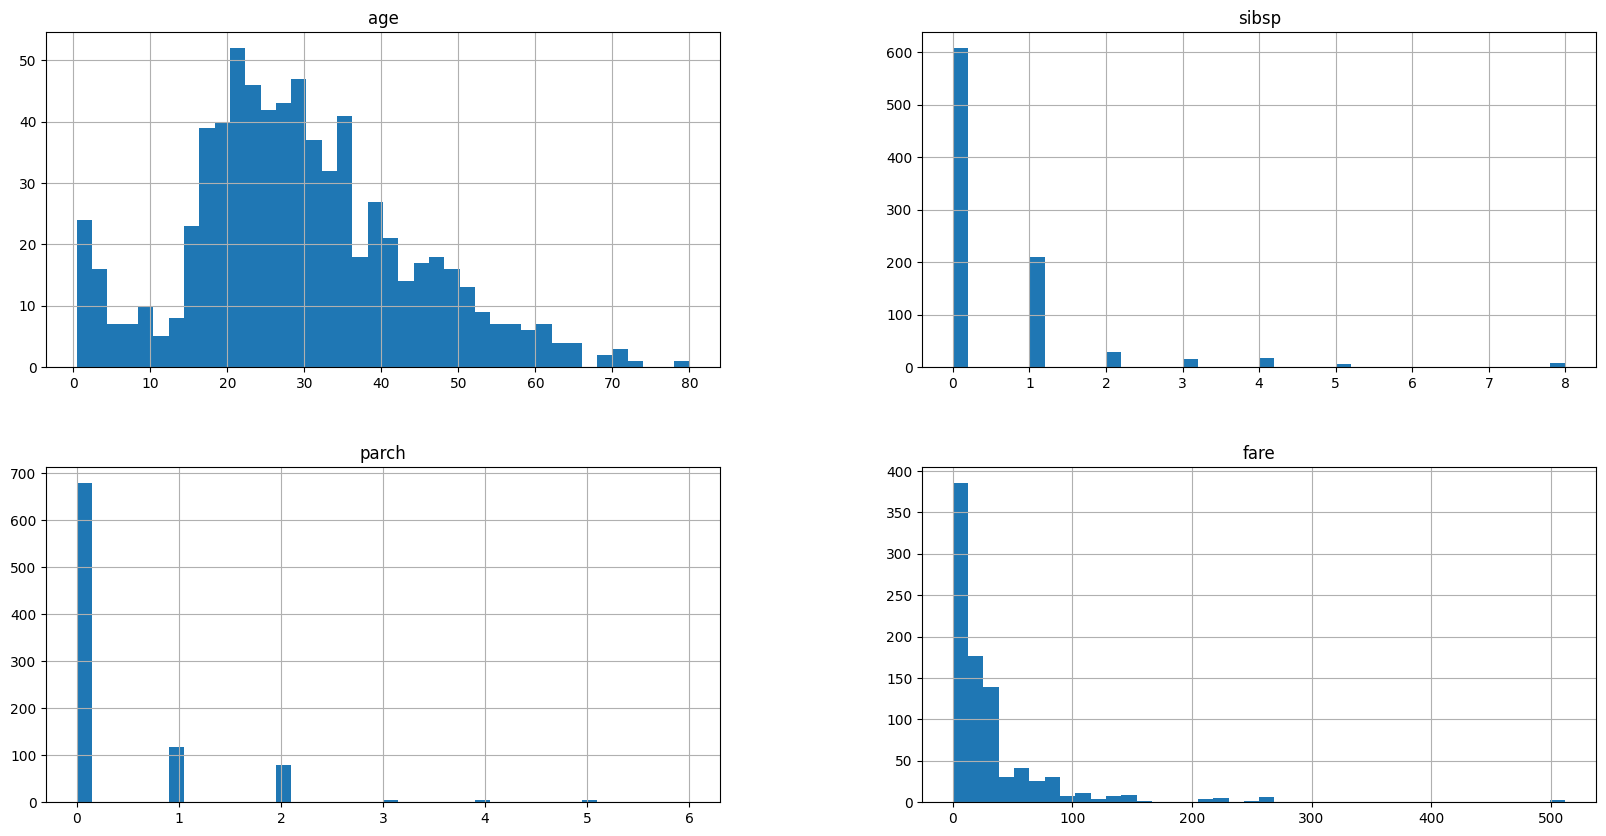

In [10]:
# Numerical cols
num_cols = ['age', 'sibsp', 'parch', 'fare']
df[num_cols].hist(figsize=(20, 10), bins=40)
plt.show()

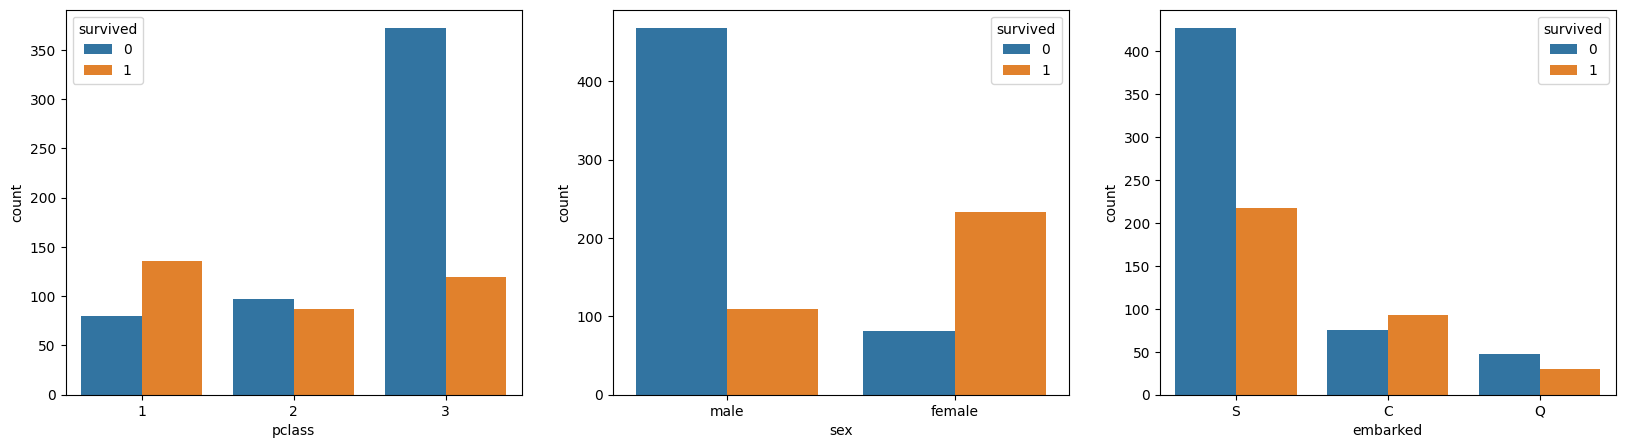

In [11]:
# Categorical cols
categ_cols = ['pclass', 'sex', 'embarked']
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, col in enumerate(categ_cols):
    sns.countplot(data=df, x=col, ax=axes[i], hue="survived")
plt.show()

## `Feature Engineering`

In [12]:
# Add 1 to add the passenger himself
df['family_size'] = df['sibsp'] + df['parch'] + 1

# Make another column if he is alone or not
def is_alone(x):
    if x > 1:
        return 0
    else:
        return 1
# apply
df['is_alone'] = df['family_size'].apply(is_alone)

In [13]:
# Check now
df[['sibsp', 'parch', 'family_size', 'is_alone']].head()

,sibsp,parch,family_size,is_alone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


## `Split Dataset`

In [14]:
df.columns

Index(['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked', 'family_size',
       'is_alone'],
      dtype='object')

In [15]:
# to X & y
choosen_features = ["pclass", "sex", "age", "sibsp", "parch", "family_size", "is_alone", "fare", "embarked"]
X = df[choosen_features]
y = df['survived']

# to train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=True, random_state=42, stratify=y)

In [16]:
# Check shapes
print("X_train shape", X_train.shape)
print("y_train shape", y_train.shape)
print()
print("X_test shape", X_test.shape)
print("y_test shape", y_test.shape)

X_train shape (712, 9)
y_train shape (712,)

X_test shape (179, 9)
y_test shape (179,)


## `Preporcessing`

In [17]:
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,family_size,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1


In [18]:
# divide into subsets
num_cols = ["age", "fare"]
categ_cols = ["sex", "embarked"]
ready_cols = list(set(X_train.columns) - set(num_cols) - set(categ_cols))

# check
print("Numerical cols: ", num_cols)
print("Categorical cols: ", categ_cols)
print("Ready cols: ", ready_cols)

Numerical cols:  ['age', 'fare']
Categorical cols:  ['sex', 'embarked']
Ready cols:  ['sibsp', 'family_size', 'parch', 'pclass', 'is_alone']


In [19]:
# Numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
categ_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"))
])

# Ready pipeline
ready_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Combine all
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('categ', categ_pipeline, categ_cols),
    ('ready', ready_pipeline, ready_cols)
])

# Apply
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

In [20]:
# Check shapes again
print("X_train_final shape", X_train_final.shape)
print("y_train shape", y_train.shape)
print()
print("X_test_final shape", X_test_final.shape)
print("y_test shape", y_test.shape)

X_train_final shape (712, 10)
y_train shape (712,)

X_test_final shape (179, 10)
y_test shape (179,)


In [21]:
# Artifcats folder
ARTIFACTS_FOLDER_PATH = os.path.join(os.getcwd(), "artifacts")
os.makedirs(ARTIFACTS_FOLDER_PATH, exist_ok=True)

In [22]:
# Dump pipeline
joblib.dump(preprocessor, os.path.join(ARTIFACTS_FOLDER_PATH, "preprocessor.joblib"))

['/content/artifacts/preprocessor.joblib']

-----

## `Random forest`

In [23]:
# Using SMOTE
#Majority class = 0 → not survived , Minority class = 1 → survived
#sampling_strategy=0.7 → after resampling, the minority class will be 70% of the majority class
over_sampling = SMOTE(sampling_strategy=0.7, k_neighbors=5, random_state=45)
X_train_resampled, y_train_resampled = over_sampling.fit_resample(X_train_final, y_train)

counter_y_train = Counter(y_train)
print("Class distribution in y_train (before resampling):", counter_y_train)
counter_y_train_resampled = Counter(y_train_resampled)
print("Class distribution in y_train (after resampling):", counter_y_train_resampled)

Class distribution in y_train (before resampling): Counter({0: 439, 1: 273})
Class distribution in y_train (after resampling): Counter({0: 439, 1: 307})


In [24]:
# RF with SMOTE
forest_clf = RandomForestClassifier(n_estimators=150, max_depth=5, random_state=45)
forest_clf.fit(X_train_resampled, y_train_resampled)

# Predict and evaluate
y_pred_train_forest = forest_clf.predict(X_train_final)
y_pred_test_forest = forest_clf.predict(X_test_final)

# Using f1_score
score_train_forest = f1_score(y_train, y_pred_train_forest)
score_test_forest = f1_score(y_test, y_pred_test_forest)

print(f'The f1_score using RF model for Training Dataset with SMOTE is {score_train_forest*100:.3f}')
print(f'The f1_score using RF model for Testing Dataset with SMOTE is {score_test_forest*100:.3f}')

The f1_score using RF model for Training Dataset with SMOTE is 80.000
The f1_score using RF model for Testing Dataset with SMOTE is 74.194


In [25]:
# tunning
forest_base_clf = RandomForestClassifier(n_estimators=150, max_depth=5, random_state=45)

params_best_grid = {
        'n_estimators': np.arange(100, 450, 50),
        'max_depth': np.arange(6, 14, 2)
}
grid_search_forest = GridSearchCV(estimator=forest_base_clf, param_grid=params_best_grid, cv=5, n_jobs=-1, scoring="f1", verbose=4)
grid_search_forest.fit(X_train_resampled, y_train_resampled)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(max_depth=5, n_estimators=150,
                                              random_state=45),
             n_jobs=-1,
             param_grid={'max_depth': array([ 6,  8, 10, 12]),
                         'n_estimators': array([100, 150, 200, 250, 300, 350, 400])},
             scoring='f1', verbose=4)

In [26]:
# Best parameters
print("Best Parameters:", grid_search_forest.best_params_)

Best Parameters: {'max_depth': np.int64(10), 'n_estimators': np.int64(100)}


In [27]:
# Train with best model
best_rf = grid_search_forest.best_estimator_
best_rf.fit(X_train_resampled, y_train_resampled)

# Predict
y_pred_train_forest = best_rf.predict(X_train_final)
y_pred_test_forest = best_rf.predict(X_test_final)

In [28]:
# F1 scores
score_train_forest = f1_score(y_train, y_pred_train_forest)
score_test_forest = f1_score(y_test, y_pred_test_forest)

print(f"Best RF f1_score (Train): {score_train_forest*100:.3f}")
print(f"Best RF f1_score (Test): {score_test_forest*100:.3f}")

Best RF f1_score (Train): 93.282
Best RF f1_score (Test): 76.336


## `Basic NN Model`

In [29]:
tf.random.set_seed(45)

In [30]:
X_train_final.shape

(712, 10)

In [31]:
# build a simple NN model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(units=128, activation="relu", input_shape=(X_train_final.shape[1],)),
    tf.keras.layers.Dense(units=64, activation="relu"),
    tf.keras.layers.Dense(units=32, activation="relu"),
    tf.keras.layers.Dense(units=16, activation="relu"),
    tf.keras.layers.Dense(units=1, activation="sigmoid")
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

* layer 1 params 10*128+ 128 bias for each neuron  = 1408
* layer 2 params 128*64+ 64 bias for each neuron =8256

In [32]:
# compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss="binary_crossentropy",
              metrics=['accuracy'])

# Fitting
history = model.fit(X_train_final, y_train,
          validation_split=0.2,
          epochs=100,
          batch_size=32)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.5774 - loss: 0.6677 - val_accuracy: 0.5944 - val_loss: 0.6232
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5944 - loss: 0.6201 - val_accuracy: 0.6993 - val_loss: 0.5893
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6747 - loss: 0.5928 - val_accuracy: 0.7762 - val_loss: 0.5551
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7201 - loss: 0.5698 - val_accuracy: 0.7832 - val_loss: 0.5245
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7595 - loss: 0.5495 - val_accuracy: 0.7972 - val_loss: 0.5064
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7709 - loss: 0.5349 - val_accuracy: 0.8112 - val_loss: 0.4861
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7804 - loss: 0.5183 - val_accuracy: 0.8182 - val_loss: 0.4762
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7893 - loss: 0.5020 - val_accuracy: 0.7972

* 18 for # of batchs  ->  batch_size=32 , 712 instance so 712 * 0.8 for train / 32 = 18 batch

In [33]:
# Evaluate on test
test_loss, test_acc = model.evaluate(X_test_final, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} %")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.7800 - loss: 0.7525
Test Loss: 0.7716
Test Accuracy: 0.7765 %


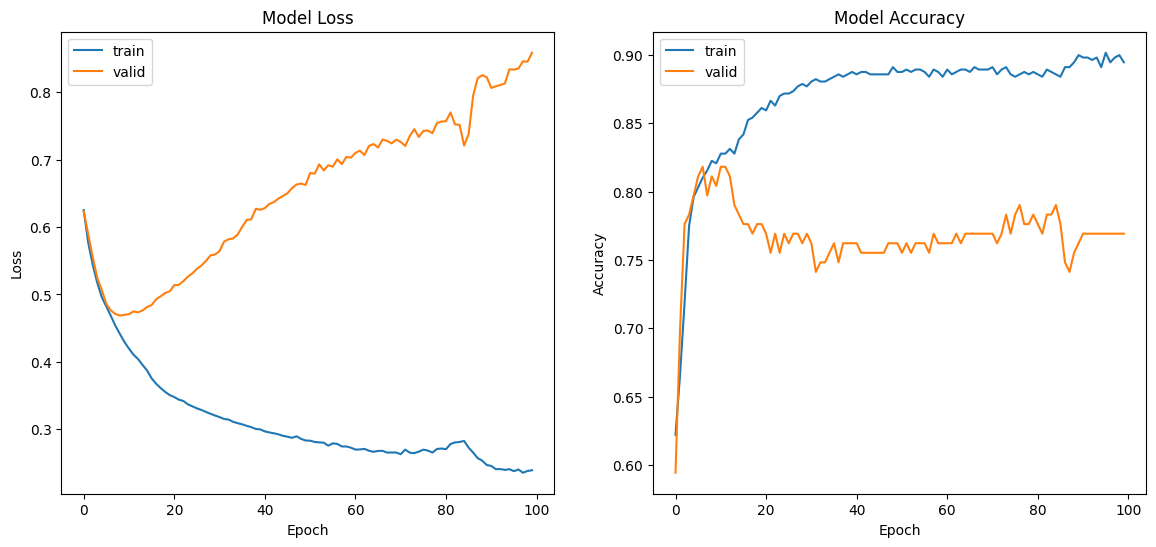

In [34]:
# Visulalize history
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
plt.sca(ax[0])
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='valid')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.sca(ax[1])
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='valid')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## `Enhancing Model`

In [35]:
# build a simple NN model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(units=128, activation="relu", input_shape=(X_train_final.shape[1],)),
    tf.keras.layers.Dropout(0.5, seed=97),
    tf.keras.layers.Dense(units=64, activation="relu"),
    tf.keras.layers.Dense(units=32, activation="relu"),
    tf.keras.layers.Dropout(0.5, seed=97),
    tf.keras.layers.Dense(units=16, activation="relu"),
    tf.keras.layers.Dropout(0.5, seed=97),
    tf.keras.layers.Dense(units=1, activation="sigmoid"),
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss="binary_crossentropy",
              metrics=['accuracy'])

# Fitting
history = model.fit(X_train_final, y_train,
          validation_split=0.2,
          epochs=100,
          batch_size=32)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.4992 - loss: 0.7541 - val_accuracy: 0.5944 - val_loss: 0.6813
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5417 - loss: 0.7229 - val_accuracy: 0.5944 - val_loss: 0.6769
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5305 - loss: 0.6926 - val_accuracy: 0.5944 - val_loss: 0.6658
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5403 - loss: 0.6760 - val_accuracy: 0.5944 - val_loss: 0.6483
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5914 - loss: 0.6559 - val_accuracy: 0.5944 - val_loss: 0.6316
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5605 - loss: 0.6786 - val_accuracy: 0.5944 - val_loss: 0.6209
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5738 - loss: 0.6503 - val_accuracy: 0.5944 - val_loss: 0.6113
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5772 - loss: 0.6491 - val_accuracy: 0.6014 -

In [37]:
# Evaluate on test
test_loss, test_acc = model.evaluate(X_test_final, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} %")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7925 - loss: 0.4920
Test Loss: 0.4911
Test Accuracy: 0.7989 %


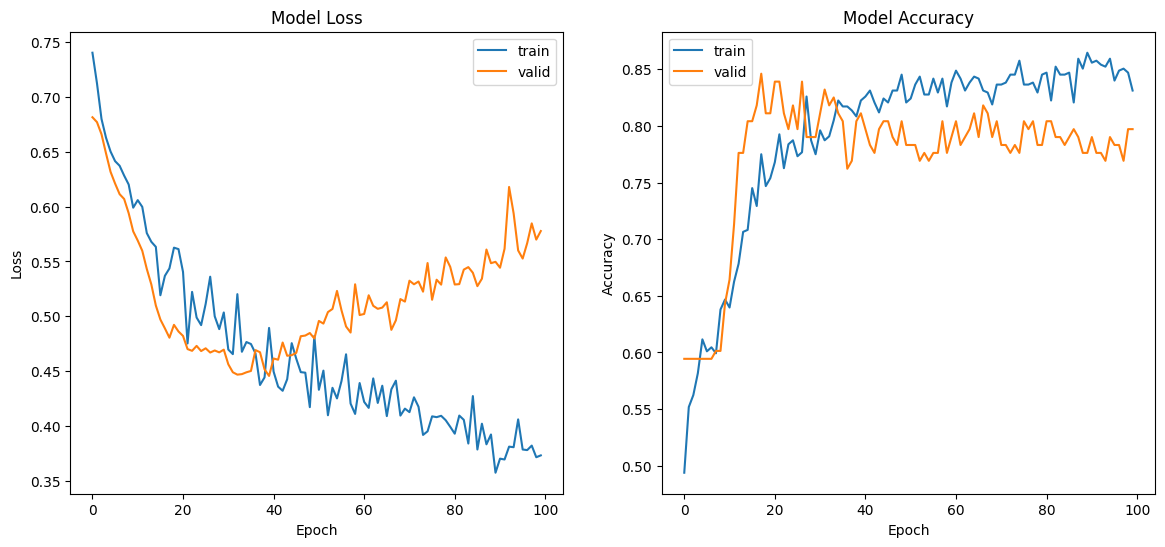

In [38]:
# Visulalize history
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
plt.sca(ax[0])
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='valid')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.sca(ax[1])
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='valid')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## `Enhancing the Model`

In [39]:
# Try add a reguralizer l2
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2=0.01), input_shape=(X_train_final.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2=0.01)),
    tf.keras.layers.Dense(32, activation='relu', kernel_regularizer="l2"),
    tf.keras.layers.Dense(16, activation='relu', kernel_regularizer="l2"),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])


# Early Stopping
early_stopp = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True)

# Fit
histroy = model.fit(X_train_final, y_train,
                    validation_split=0.2,
                    epochs=100,
                    batch_size=32,
                    callbacks=[early_stopp])

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.5569 - loss: 2.2935 - val_accuracy: 0.6783 - val_loss: 2.0232
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6584 - loss: 1.9492 - val_accuracy: 0.6923 - val_loss: 1.7215
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6676 - loss: 1.6698 - val_accuracy: 0.6993 - val_loss: 1.4794
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6853 - loss: 1.4491 - val_accuracy: 0.7273 - val_loss: 1.2966
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7056 - loss: 1.2787 - val_accuracy: 0.7273 - val_loss: 1.1623
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7160 - loss: 1.1505 - val_accuracy: 0.7343 - val_loss: 1.0594
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7250 - loss: 1.0564 - val_accuracy: 0.7832 - val_loss: 0.9557
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7382 - loss: 0.9723 - val_accuracy: 0.7972 -

In [41]:
# Evaluate on test
test_loss, test_acc = model.evaluate(X_test_final, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} %")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7690 - loss: 0.5492
Test Loss: 0.5292
Test Accuracy: 0.7989 %


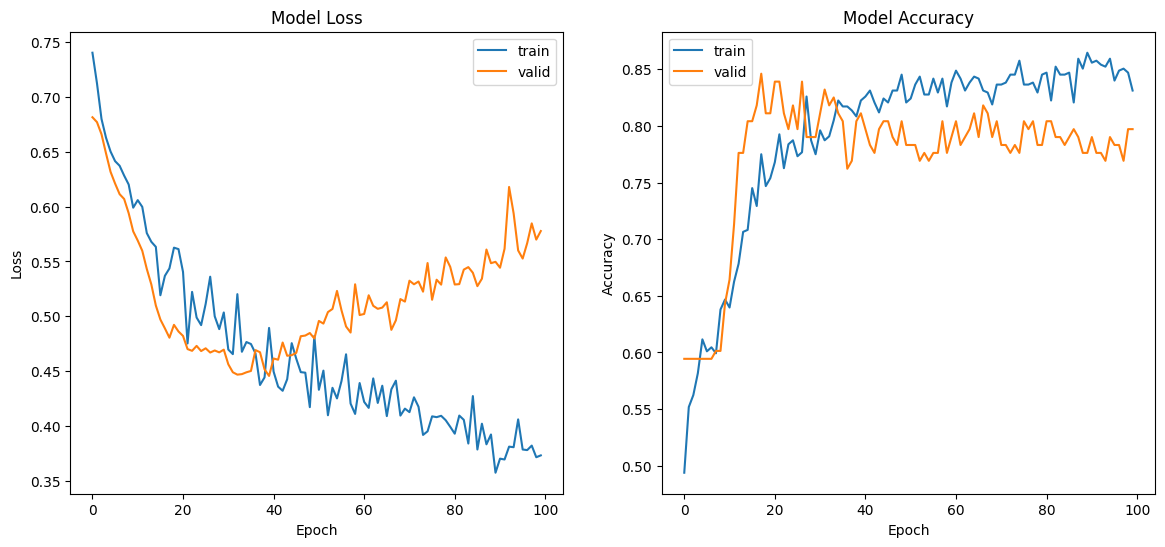

In [42]:
# Visulalize history
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
plt.sca(ax[0])
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='valid')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.sca(ax[1])
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='valid')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## `Using Keras-Tuner`

In [43]:
def build_model(hp):
  model = tf.keras.models.Sequential([
      tf.keras.layers.Input(shape=(X_train_final.shape[1],)),

      # First Layer
      tf.keras.layers.Dense(units=hp.Int('units_1', min_value=32, max_value=512, step=32),
                            activation="relu"),
      # Dropout
      tf.keras.layers.Dropout(hp.Float('dropout_1', min_value=0.2, max_value=0.5, step=0.1)),

      # Second Layer
      tf.keras.layers.Dense(units=hp.Int('units_2', min_value=32, max_value=512, step=32),
                            activation="relu"),
      # Dropout
      tf.keras.layers.Dropout(hp.Float('dropout_2', min_value=0.2, max_value=0.5, step=0.1)),

      # Ouptut layer
      tf.keras.layers.Dense(1, activation="sigmoid")
  ])

  # compile model
  model.compile(
      loss="binary_crossentropy",
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      metrics=['accuracy']
  )

  return model

In [44]:
# early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

In [45]:
tuner = RandomSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=10,
    executions_per_trial=2,
    directory="hyperparameter_tuning",
    project_name="titanic_project",
    seed=174
)

In [46]:
# Running tuner
tuner.search(X_train_final, y_train,
             epochs=50,
             validation_split=0.2,
             callbacks=[early_stopping],
             )

Trial 10 Complete [00h 00m 17s]
val_accuracy: 0.8321678340435028

Best val_accuracy So Far: 0.839160829782486
Total elapsed time: 00h 02m 44s


In [47]:
best_model = tuner.get_best_models(num_models=1)[0]
best_model

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


<Sequential name=sequential, built=True>

In [48]:
# Evaluate on test
test_loss, test_acc = best_model.evaluate(X_test_final, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} %")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.7996 - loss: 0.4618
Test Loss: 0.4521
Test Accuracy: 0.8045 %


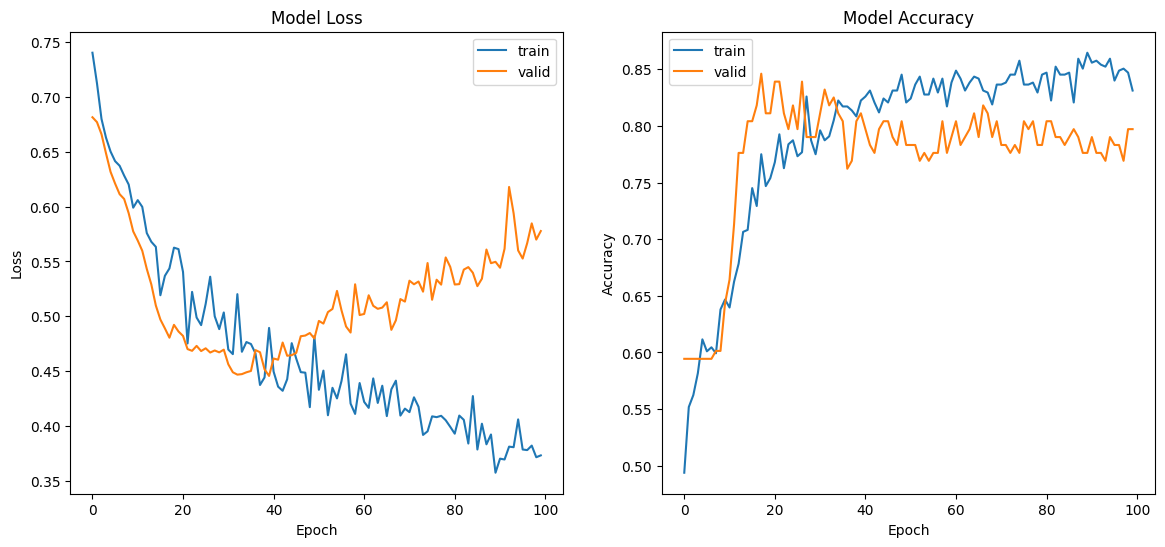

In [49]:
# Visulalize history
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
plt.sca(ax[0])
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='valid')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.sca(ax[1])
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='valid')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

----

### `Save & Load the Best Model`

In [50]:
# Save the model locally
best_model.save(os.path.join(ARTIFACTS_FOLDER_PATH, "best_model.keras"))

In [51]:
# Load pretrained model
model = tf.keras.models.load_model(os.path.join(ARTIFACTS_FOLDER_PATH, "best_model.keras"))

# Evaluate on test
test_loss, test_acc = best_model.evaluate(X_test_final, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} %")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7996 - loss: 0.4618 
Test Loss: 0.4521
Test Accuracy: 0.8045 %


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


### `Inference`

In [52]:
# Imagine that these are some samples
samples = df.sample(10, random_state=14)

# Processing
samples_processed = preprocessor.transform(samples)

# Predict
predictions = (model.predict(samples_processed) > 0.5).astype("int32")

predictions.flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step


array([0, 0, 0, 0, 0, 1, 0, 0, 0, 1], dtype=int32)

In [53]:
results = pd.DataFrame({
    'Passenger_ID': samples["passengerid"],
    'Predicted': ['Survived' if pred == 1 else 'Not Survived' for pred in predictions.flatten()],
})

results

,Passenger_ID,Predicted
75,76,Not Survived
602,603,Not Survived
119,120,Not Survived
647,648,Not Survived
115,116,Not Survived
472,473,Survived
547,548,Not Survived
735,736,Not Survived
467,468,Not Survived
759,760,Survived


-----